In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
from matplotlib import colors as mcolors
import numpy as np
import seaborn as sns
from sklearn.metrics import pairwise_distances,silhouette_score

In [3]:
base_dir = '../data/s1/original/'

dfs = []
files = next(os.walk(base_dir))[2]

for file in files:
    dfs.append(pd.read_csv(os.path.join(base_dir, file), encoding='utf-8'))

In [4]:
original_df = pd.concat(dfs, ignore_index=True, sort=False)

In [5]:
original_df = original_df.sort_values(by=['_id'])
original_df.head()

,x,y,cluster,_id
1000,0.683912,0.543504,1,0
1001,0.685701,0.551136,1,1
1002,0.612810,0.570245,1,2
1003,0.635553,0.544047,1,3
1004,0.653693,0.605594,1,4


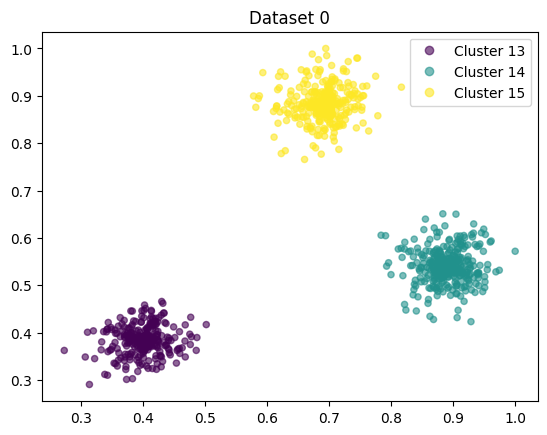

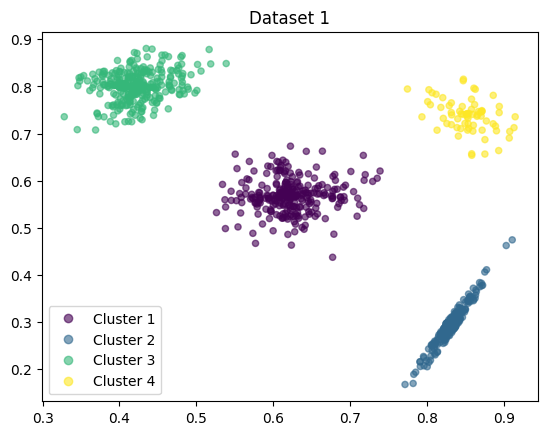

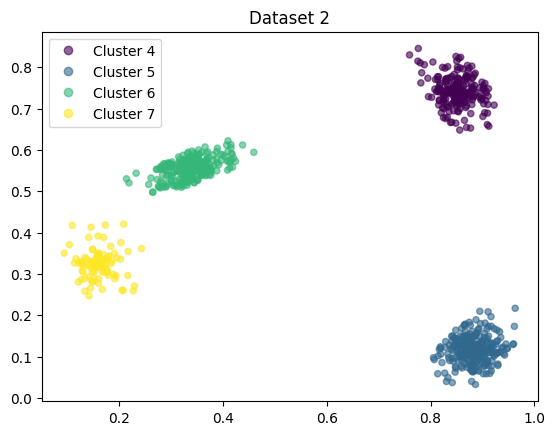

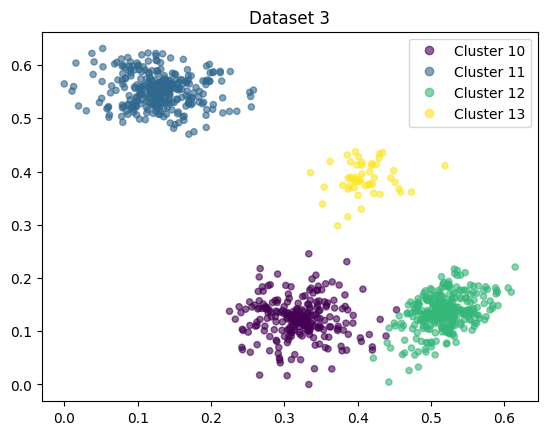

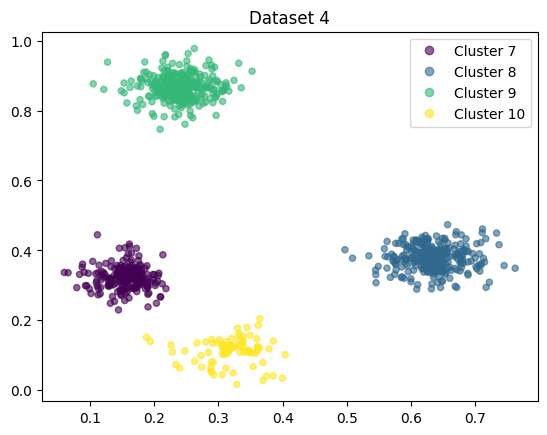

In [6]:
for index, df in enumerate(dfs):
    fig, ax = plt.subplots()
    scatter = plt.scatter(df["x"], df["y"], c=df['cluster'], alpha = 0.6, s=20)
    ax.legend(handles=scatter.legend_elements()[0], labels=map(lambda x: 'Cluster ' + str(x), df['cluster'].unique()))
    ax.set_title(f"Dataset {index}")

In [7]:
def cluster_wise_f_measure(data):
    sum = 0
    unique_clusters_predicted = sorted(data['cluster'].unique())
    for cluster in unique_clusters_predicted:
    	predicted_cluster = data[data['cluster'] == cluster]
    	true_cluster = cluster_with_max_shared(predicted_cluster, data)
    	sum += f_measure(set(predicted_cluster['_id']), set(true_cluster['_id']))
    
    length = len(unique_clusters_predicted)
    return (sum / length)

def f_measure(pred, true):
    value = (2 * len(pred & true)) / (len(true) + len(pred))
    return value


def cluster_with_max_shared(predicted_cluster, data):
	predicted = set(predicted_cluster['_id'])
	true = data['actual_cluster'].unique()
	max_cluster = 0
	max_session = 0

	for label in true:
		cluster = data[data['actual_cluster'] == label]
		same_cluster = len(predicted & set(cluster['_id']))
		if same_cluster > max_cluster:
			max_cluster = same_cluster
			max_session = label
	return data[data['actual_cluster'] == max_session]

def cluster_wise_jaccard(data):
	sum = 0
	unique_clusters_predicted = sorted(data['cluster'].unique())
	for cluster in unique_clusters_predicted:
		predicted_cluster = data[data['cluster'] == cluster]
		true_cluster = cluster_with_max_shared(predicted_cluster, data)
		sum += jaccard_measure(set(predicted_cluster['_id']), set(true_cluster['_id']))

	length = len(unique_clusters_predicted)
	return (sum / length)


def jaccard_measure(y_true, y_pred):
    return (len(y_pred & y_true)) / (len(y_true) + len(y_pred) - len(y_true & y_pred))

In [26]:
result_metrics = {}

def calculate_distances(data):
    return pairwise_distances(data,data)

def eda_clustering(window=30, data_type='original', is_included=False, num_segments = 4):
    base_dir = f'../results/s1/{data_type}/tabular/{window}/'
    df = pd.read_csv(os.path.join(base_dir, 'final_clustering.csv'), encoding='utf-8')
    print(df.shape)
    # df = df[df['segment']<=num_segments]

    if is_included:
        df = df[df['is_included']==True]
    
    df = df.rename(columns={'ids': '_id', 'target': 'actual_cluster'})

    palette = sns.color_palette('hls', n_colors=len(set(df['cluster'])))
    
    sns.scatterplot(x=df['x'], y=df['y'], hue=df['cluster'], palette=palette).set(title=f"Window {window}")
    plt.xticks(np.arange(0, 1.1, 0.1))  
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.show()

    distances = calculate_distances(df[df.columns[:-6]].to_numpy(copy=True))
    if len(df['cluster'].unique()) > 1:
        SI = silhouette_score(distances, df['cluster'])
    else:
        SI = None
    F1 = cluster_wise_f_measure(df)
    JI = cluster_wise_jaccard(df)

    result_metrics[window] = [SI, F1, JI, int(len(df['cluster'].unique()))]


In [9]:
for window in [3,4,6,8,12,24,30,32,48]:
    eda_clustering(window=window, data_type='continuous_previous', is_included=False, num_segments=4)
    # eda_clustering(window=window, data_type='original', is_included=True, num_segments=4)

results_df = pd.DataFrame(result_metrics).T
results_df.columns = ['SI', 'F1', 'JI', 'cluster_count']
results_df

FileNotFoundError: [Errno 2] No such file or directory: '../results/s1/continuous_previous/tabular/3/final_clustering.csv'

In [ ]:
distances = calculate_distances(original_df[original_df.columns[:-2]].to_numpy(copy=True))
if len(original_df['cluster'].unique()) > 1:
    SI = silhouette_score(distances, original_df['cluster'])
else:
    SI = None
# F1 = cluster_wise_f_measure(df)
# JI = cluster_wise_jaccard(df)

SI, int(len(original_df['cluster'].unique()))

(0.697662141534048, 15)

(5000, 7)


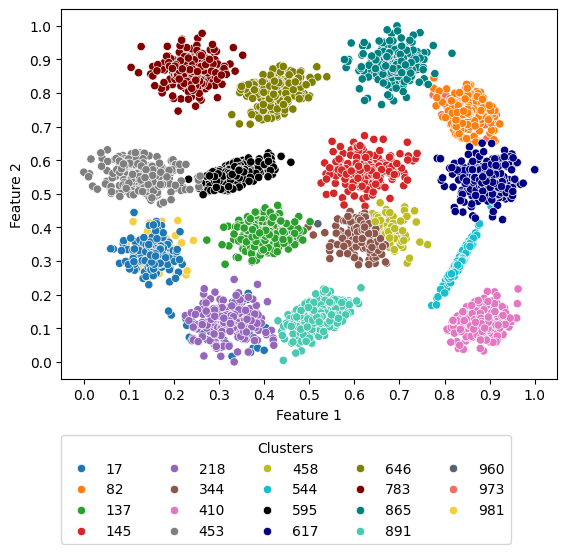

In [78]:
df = pd.read_csv('total.csv', encoding='utf-8')
print(df.shape)
# df = df[df['segment']<=num_segments]

colors = ['#1f77b4', 
        '#ff7f0e', 
        '#2ca02c', 
        '#d62728',
        '#9467bd', 
        '#8c564b', 
        '#e377c2', 
        '#7f7f7f', 
        '#bcbd22', 
          '#17becf',
'#000000',
'#000080',
'#808000',
'#800000',
'#008080',
'#48c9b0',
'#566573',
'#ec7063',
'#f4d03f']
        

palette = sns.color_palette(colors, n_colors=len(set(df['cluster'])))

sns.scatterplot(x=df['x'], y=df['y'], hue=df['cluster'], palette=palette)
plt.xticks(np.arange(0, 1.1, 0.1))  
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='center left', bbox_to_anchor=(0.0, -0.3), ncol=5, borderaxespad=0, title='Clusters')
plt.show()

         

In [80]:
df1 = pd.read_csv('total.csv', encoding='utf-8')
length = len(df1.cluster.unique())
labels = np.arange(1, 20, 1)

new_cluster_labels = {}
for label, new_label in zip(df.cluster.unique(), labels):
    new_cluster_labels[label] = new_label

df['cluster_copy'] = df['cluster']
df['cluster_copy'] = df['cluster_copy'].apply(lambda x: new_cluster_labels[x])
df


,Unnamed: 0,x,y,cluster,_id,actual_cluster,cluster_ids,cluster_copy
0,0,0.683912,0.543504,145,0,1,0,1
1,1,0.685701,0.551136,145,1,1,0,1
2,2,0.612810,0.570245,145,2,1,0,1
3,3,0.635553,0.544047,145,3,1,0,1
4,4,0.653693,0.605594,145,4,1,0,1
...,...,...,...,...,...,...,...,...
4995,4995,0.685256,0.872976,865,4995,15,0,19
4996,4996,0.713279,0.883875,865,4996,15,0,19
4997,4997,0.669584,0.880943,865,4997,15,0,19
4998,4998,0.615436,0.878154,865,4998,15,0,19


{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19}
{646, 137, 783, 145, 17, 410, 544, 960, 453, 458, 973, 82, 595, 981, 344, 218, 865, 617, 891}


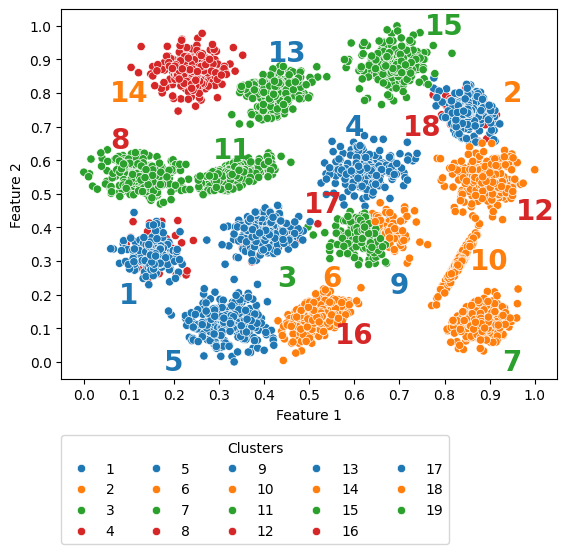

In [104]:
colors = ['#1f77b4', 
        '#ff7f0e', 
        '#2ca02c', 
        '#d62728']
        
print(set(df['cluster_copy']))
print(set(df['cluster']))
palette = sns.color_palette(colors, n_colors=len(set(df['cluster_copy'])))

sns.scatterplot(x=df['x'], y=df['y'], hue=df['cluster_copy'], palette=palette)
plt.xticks(np.arange(0, 1.1, 0.1))  
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

df1 = pd.DataFrame({
    "cluster": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
    "x": [0.1, 0.95, 0.45, 0.6, 0.2, 0.55, 0.95, 0.08, 0.7, 0.9, 0.33, 1, 0.45, 0.1, 0.8, 0.6, 0.53, 0.75],
    "y": [0.2, 0.8, 0.25, 0.7, 0, 0.25, 0, 0.66, 0.23, 0.3, 0.63, 0.45, 0.92, 0.8, 1, 0.08, 0.47,0.7],
    "color": ['#1f77b4', '#ff7f0e', '#2ca02c', '#1f77b4', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#1f77b4', '#ff7f0e','#2ca02c','#d62728', '#d62728', '#d62728']
})
for x, y, cluster, color in zip(df1.x, df1.y, df1.cluster, df1.color):
    plt.annotate(cluster, 
                 (x,y),
                 horizontalalignment='center',
                 verticalalignment='center',
                 size=20, weight='bold',
                 color=color)
plt.legend(loc='center left', bbox_to_anchor=(0.0, -0.3), ncol=5, borderaxespad=0, title='Clusters',)
plt.show()


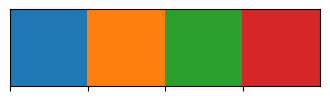

In [19]:
#define a custom palette
customPalette = ['#1f77b4', 
        '#ff7f0e', 
        '#2ca02c', 
        '#d62728']
sns.set_palette(customPalette)
sns.palplot(customPalette)

In [3]:
df0 = pd.read_csv("0.csv")
df1 = pd.read_csv("1.csv")
df2 = pd.read_csv("2.csv")
df3 = pd.read_csv("3.csv")
df4 = pd.read_csv("4.csv")

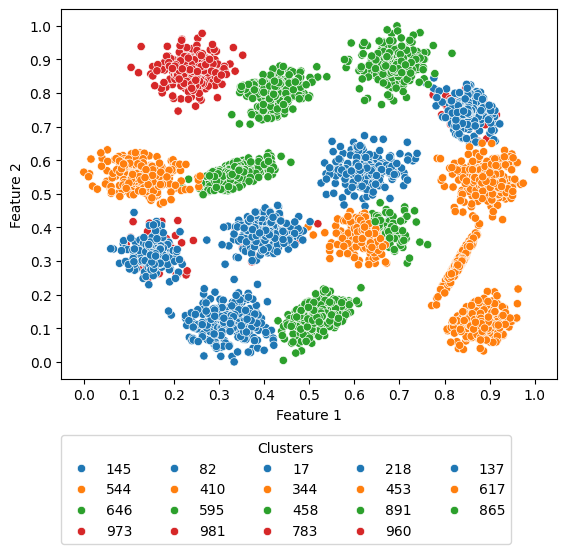

In [5]:
colors = ['#1f77b4', 
        '#ff7f0e', 
        '#2ca02c', 
        '#d62728']
        
# print(set(df['cluster_copy']))
# print(set(df['cluster']))
palette0 = sns.color_palette(colors, n_colors=len(set(df0['cluster'])))
palette1 = sns.color_palette(colors, n_colors=len(set(df1['cluster'])))
palette2 = sns.color_palette(colors, n_colors=len(set(df2['cluster'])))
palette3 = sns.color_palette(colors, n_colors=len(set(df3['cluster'])))
palette4 = sns.color_palette(colors, n_colors=len(set(df4['cluster'])))

sns.scatterplot(x=df0['x'], y=df0['y'], hue=df0['cluster'], palette=palette0)
sns.scatterplot(x=df1['x'], y=df1['y'], hue=df1['cluster'], palette=palette1)
sns.scatterplot(x=df2['x'], y=df2['y'], hue=df2['cluster'], palette=palette2)
sns.scatterplot(x=df3['x'], y=df3['y'], hue=df3['cluster'], palette=palette3)
sns.scatterplot(x=df4['x'], y=df4['y'], hue=df4['cluster'], palette=palette4)
plt.xticks(np.arange(0, 1.1, 0.1))  
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

df1 = pd.DataFrame({
    "cluster": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
    "x": [0.1, 0.95, 0.45, 0.6, 0.2, 0.55, 0.95, 0.08, 0.7, 0.9, 0.33, 1, 0.45, 0.1, 0.8, 0.6, 0.53, 0.75],
    "y": [0.2, 0.8, 0.25, 0.7, 0, 0.25, 0, 0.66, 0.23, 0.3, 0.63, 0.45, 0.92, 0.8, 1, 0.08, 0.47,0.7],
    "color": ['#1f77b4', '#ff7f0e', '#2ca02c', '#1f77b4', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#1f77b4', '#ff7f0e','#2ca02c','#d62728', '#d62728', '#d62728']
})
# for x, y, cluster, color in zip(df1.x, df1.y, df1.cluster, df1.color):
#     plt.annotate(cluster, 
#                  (x,y),
#                  horizontalalignment='center',
#                  verticalalignment='center',
#                  size=20, weight='bold',
#                  color=color)
plt.legend(loc='center left', bbox_to_anchor=(0.0, -0.3), ncol=5, borderaxespad=0, title='Clusters',)
plt.show()